## 0.1 Prepare dataset

In [ ]:
import requests
import tarfile
from pathlib import Path
import shutil
import tempfile

# Dataset URL
dataset_url = "http://www.cs.cmu.edu/~dbamman/data/booksummaries.tar.gz"

# Use path for temporary files, then copy to data directory
tmp_dir = Path(tempfile.gettempdir())
dataset_file = tmp_dir / "booksummaries.tar.gz"

# Path to data directory
data_dir = Path.cwd()
target_file = data_dir / "booksummaries.txt"

if not target_file.exists():
    print(f"Downloading CMU Book Summary Dataset from {dataset_url}...")

    # Download the file to /tmp
    response = requests.get(dataset_url, stream=True)
    response.raise_for_status()

    dataset_file.write_bytes(response.content)
    print(f"Downloaded to {dataset_file}")

    # Extract the archive
    print("Extracting archive...")
    with tarfile.open(dataset_file, "r:gz") as tar:
        tar.extractall(path=tmp_dir, filter='data')

    # Copy file to data directory
    extracted_file = tmp_dir / "booksummaries" / "booksummaries.txt"
    shutil.copy(str(extracted_file), str(target_file))

    # Cleanup
    shutil.rmtree(tmp_dir / "booksummaries")
    dataset_file.unlink()

    print(f"✓ Dataset ready: {target_file}")
else:
    print(f"✓ Dataset already exists: {target_file}")

## 1. Imports

In [ ]:
# Optional cuda install
%pip install torch --index-url https://download.pytorch.org/whl/cu126

In [ ]:
%pip install bertopic
%pip install bertopic[visualization]
%pip install pandas scikit-learn nltk
%pip install sentence-transformers umap-learn plotly matplotlib

In [ ]:
import pandas as pd
from bertopic import BERTopic
import nltk
from sklearn.feature_extraction.text import CountVectorizer
import os
import numpy as np
from umap import UMAP
import plotly.express as px
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('punkt')  # for tokenization
nltk.download('wordnet')  # contains word lemmas
nltk.download('omw-1.4')  # for lemmatization
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import torch

## 2. Loading and preliminary data cleaning

We load the dataset and remove rows that do not contain plot summaries. We also drop duplicate book titles to ensure each book is unique.

In [2]:
file_path = 'booksummaries.txt'

if not os.path.exists(file_path):
    print(f"File {file_path} not foud.")
else:
    column_names = ['wiki_id', 'freebase_id', 'book_title', 'author', 'publication_date', 'genres', 'plot_summary']
    df = pd.read_csv(file_path, sep='\t', header=None, names=column_names)

    df.dropna(subset=['plot_summary'], inplace=True)
    df.drop_duplicates(subset=['book_title'], inplace=True)

    print(f"Loaded and processed {len(df)} books.")
    print("Sample Data:")
    display(df.head())

Loaded and processed 16277 books.
Sample Data:


,wiki_id,freebase_id,book_title,author,publication_date,genres,plot_summary
0,620,/m/0hhy,Animal Farm,George Orwell,1945-08-17,"{""/m/016lj8"": ""Roman \u00e0 clef"", ""/m/06nbt"":...","Old Major, the old boar on the Manor Farm, ca..."
1,843,/m/0k36,A Clockwork Orange,Anthony Burgess,1962,"{""/m/06n90"": ""Science Fiction"", ""/m/0l67h"": ""N...","Alex, a teenager living in near-future Englan..."
2,986,/m/0ldx,The Plague,Albert Camus,1947,"{""/m/02m4t"": ""Existentialism"", ""/m/02xlf"": ""Fi...",The text of The Plague is divided into five p...
3,1756,/m/0sww,An Enquiry Concerning Human Understanding,David Hume,NaN,NaN,The argument of the Enquiry proceeds by a ser...
4,2080,/m/0wkt,A Fire Upon the Deep,Vernor Vinge,NaN,"{""/m/03lrw"": ""Hard science fiction"", ""/m/06n90...",The novel posits that space around the Milky ...


### 2.1 Better data cleaning

In [3]:
import re
import html


def clean_summary_text(text):
    """
    Cleans the plot summary text by removing HTML tags, wiki markup, and other unwanted patterns.
    """
    if not isinstance(text, str):
        return ""

    text = html.unescape(text)
    text = re.sub(r'==+.*?==+', ' ', text)
    text = re.sub(r'~Plot outline description~', '', text, flags=re.IGNORECASE)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\{\{.*?\}\}', ' ', text, flags=re.DOTALL)
    text = re.sub(r'\[\[(?:[^\|\]]*\|)?([^\]]+)\]\]', r'\1', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


df['plot_summary'] = df['plot_summary'].apply(clean_summary_text)

num_books_before = len(df)
print(f"Number of books before cleaning: {num_books_before}")

MIN_LENGTH_THRESHOLD = 300

is_valid_summary = df['plot_summary'].str.len() >= MIN_LENGTH_THRESHOLD
removed_books = df[~is_valid_summary]
df = df[is_valid_summary].reset_index(drop=True)
num_books_after = len(df)
print(
    f"Number of books after cleaning: {num_books_after} (removed {num_books_before - num_books_after} books with short summaries)")

if not removed_books.empty:
    print("\nExamples of removed books due to short summaries:")
    display(removed_books[['book_title', 'plot_summary']].head(10))

Number of books before cleaning: 16277
Number of books after cleaning: 15193 (removed 1084 books with short summaries)

Examples of removed books due to short summaries:


,book_title,plot_summary
387,Science and Health with Key to the Scriptures,Science and Health encapsulates the teachings ...
678,More Joy in Heaven,"The story of Kip Caley, an ex-criminal, intent..."
722,Article 23,Academy plebe Justin Bell is excited about his...
765,Operation Shylock: A Confession,"The novel follows narrator ""Philip Roth"" on a ..."
822,Red Rabbit,"Jack Ryan, the Central Intelligence Agency, an..."
1116,The Whole Man,After a riot in a near-future England where te...
1303,"A Child Called ""It""",The book is written as a memoir which covers p...
1388,Tieta do Agreste,Antonieta returns from São Paulo to her native...
1396,Addictive Aversions,The book is a follow-up to Anonymous Constella...
1397,Angels of Youth,"It is divided into four sections, Ceres, Stanz..."


## 3. Generating embeddings
Generating Embeddings with Sentence Transformers, more specifically the 'all-mpnet-base-v2' model. It provides 768-dimensional embeddings.
It will run on GPU if available, otherwise on CPU.

In [4]:
from sentence_transformers import SentenceTransformer

if 'df' in locals():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=device)
    summaries = df['plot_summary'].tolist()

    print(f"Starting to generate embeddings for {len(summaries)} books...")
    embeddings = model.encode(
        summaries,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=64
    )
    print(f"Created embeddings with shape: {embeddings.shape}")
else:
    print("No data present")

Using device: cuda
Starting to generate embeddings for 15193 books...


Batches: 100%|██████████| 238/238 [01:26<00:00,  2.75it/s]

Created embeddings with shape: (15193, 768)


Embeddings can be saved to a file for later use, mainly for backend.

In [27]:
embeddings_file = 'book_embeddings.npy'

print("Saving embeddings to file...")
np.save(embeddings_file, embeddings)

print(f"Embeddings saved to {embeddings_file}. Data shape: {embeddings.shape}")

Saving embeddings to file...
Embeddings saved to book_embeddings.npy. Data shape: (15193, 768)


## 4. Topic Modeling with BERTopic

### Text Preprocessing
To improve topic generation, we are using only nouns in topics. Because we are still using full text embeddings, it should not impact topic generation, only representation.

In [6]:
lemmatizer = WordNetLemmatizer()


def filter_nouns_single(text):
    allowed_tags = {'NN', 'NNS', 'NNP', 'NNPS'}

    words = nltk.word_tokenize(text)

    tagged = nltk.pos_tag(words)

    nouns = [
        lemmatizer.lemmatize(word)
        for word, tag in tagged
        if tag in allowed_tags and len(word) > 2
    ]

    return " ".join(nouns)


if 'df' in locals():
    print("Beginning text processing...")
    df['processed_summary'] = df['plot_summary'].apply(filter_nouns_single)
    print("Text processing finished.")

    row = df.iloc[0]

    print("--- Original ---")
    print(row['plot_summary'])
    print("\n--- Processed ---")
    print(row['processed_summary'])

Beginning text processing...
Text processing finished.
--- Original ---
Old Major, the old boar on the Manor Farm, calls the animals on the farm for a meeting, where he compares the humans to parasites and teaches the animals a revolutionary song, 'Beasts of England'. When Major dies, two young pigs, Snowball and Napoleon, assume command and turn his dream into a philosophy. The animals revolt and drive the drunken and irresponsible Mr Jones from the farm, renaming it "Animal Farm". They adopt Seven Commandments of Animal-ism, the most important of which is, "All animals are equal". Snowball attempts to teach the animals reading and writing; food is plentiful, and the farm runs smoothly. The pigs elevate themselves to positions of leadership and set aside special food items, ostensibly for their personal health. Napoleon takes the pups from the farm dogs and trains them privately. Napoleon and Snowball struggle for leadership. When Snowball announces his plans to build a windmill, Napo

### Training BERTopic

In [7]:
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.cluster import KMeans

if 'df' in locals():
    documents = df['processed_summary'].tolist()

    custom_stopwords = [
        "narrator", "character", "characters", "protagonist", "plot", "story", "book", "novel",
        "part", "series", "chapter", "volume", "edition", "version",

        "death", "life", "world", "man", "woman", "time", "year", "years", "day",
        "way", "end", "something", "someone"
    ]

    stop_words = stopwords.words('english') + custom_stopwords

    vectorizer_model = CountVectorizer(
        stop_words=stop_words,
        min_df=2,
    )

    ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

    representation_model = KeyBERTInspired()

    topic_umap = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

    hdbscan_model = HDBSCAN(min_cluster_size=25, metric='euclidean', cluster_selection_method='eom')

    kmeans_model = KMeans(n_clusters=20, random_state=42)

    topic_model = BERTopic(
        embedding_model=model,
        umap_model=topic_umap,
        hdbscan_model=kmeans_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        representation_model=representation_model,
        top_n_words=10,
        verbose=True
    )
    topics, probabilities = topic_model.fit_transform(documents, embeddings)

    print("\nModel has been trained successfully!")
    print(topic_model.get_topic_info())
else:
    print("No data present")

2025-12-28 20:49:06,637 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-28 20:49:15,573 - BERTopic - Dimensionality - Completed ✓
2025-12-28 20:49:15,574 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-28 20:49:19,324 - BERTopic - Cluster - Completed ✓
2025-12-28 20:49:19,332 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-28 20:49:22,026 - BERTopic - Representation - Completed ✓



Model has been trained successfully!
    Topic  Count                                  Name  \
0       0   1619             0_rat_attack_castle_quest   
1       1   1508             1_game_town_father_harold   
2       2   1299      2_servant_helen_elizabeth_church   
3       3   1085           3_pig_scarecrow_glinda_head   
4       4   1080        4_tardis_emperor_colony_attack   
5       5   1070            5_witness_harry_wife_house   
6       6    909   6_steinbeck_grandfather_ishmael_war   
7       7    902         7_affair_jaime_templar_lucien   
8       8    846       8_war_confederate_battle_attack   
9       9    818          9_tale_war_history_holocaust   
10     10    774             10_room_movie_town_author   
11     11    703          11_game_war_history_colossus   
12     12    575         12_author_school_friend_place   
13     13    467  13_machiavelli_virtue_context_action   
14     14    401          14_voyage_crusoe_ship_vessel   
15     15    345       15_snape_tw

In [8]:
# new_topics = topic_model.reduce_outliers(
#     documents,
#     topics,
#     embeddings=embeddings,
#     strategy="embeddings",
#     threshold=0.7
# )
# topic_model.update_topics(documents, topics=new_topics, vectorizer_model=vectorizer_model)

# topic_model.reduce_topics(documents)
# topics = topic_model.topics_

# labels = topic_model.generate_topic_labels(nr_words=2, topic_prefix=False, separator=" ")
# topic_model.set_topic_labels(labels)

df['topic'] = topic_model.topics_

# print(topic_model.get_topic_info())

### Visualizing and Analyzing Topics

**Most frequent topics**

In [9]:
if 'topic_model' in locals():
    display(topic_model.get_topic_info())
else:
    print("No df_topic")

,Topic,Count,Name,Representation,Representative_Docs
0,0,1619,0_rat_attack_castle_quest,"[rat, attack, castle, quest, enemy, prophecy, ...",[Phèdre Liliane Souverain Servant Naamah Pierr...
1,1,1508,1_game_town_father_harold,"[game, town, father, harold, room, greg, job, ...",[continuation book Flowers Attic story Cathy C...
2,2,1299,2_servant_helen_elizabeth_church,"[servant, helen, elizabeth, church, hamlet, ho...",[England Laurie Lee home Slad Gloucestershire ...
3,3,1085,3_pig_scarecrow_glinda_head,"[pig, scarecrow, glinda, head, fire, house, pe...",[Oatsie Manglehand woman Grasstrail Train body...
4,4,1080,4_tardis_emperor_colony_attack,"[tardis, emperor, colony, attack, manticore, d...",[event Mutineers Moon mutineer Anu warship Dah...
5,5,1070,5_witness_harry_wife_house,"[witness, harry, wife, house, scene, victim, j...",[New York City summer clinic New York Park Ave...
6,6,909,6_steinbeck_grandfather_ishmael_war,"[steinbeck, grandfather, ishmael, war, father,...",[Gone Wind place United States state Georgia A...
7,7,902,7_affair_jaime_templar_lucien,"[affair, jaime, templar, lucien, priest, revol...",[L'enquête Policemen patrol area Paris cry Poi...
8,8,846,8_war_confederate_battle_attack,"[war, confederate, battle, attack, operation, ...",[novel West Germany East Germany month August ...
9,9,818,9_tale_war_history_holocaust,"[tale, war, history, holocaust, house, jacob, ...",[War Peace cast character majority book figure...


**Visualization of topics as a bar chart**

This chart shows the 10 most popular topics and the keywords that define them.

In [10]:
if 'topic_model' in locals():
    display(topic_model.visualize_barchart(top_n_topics=10))
else:
    print("No df_topic")

**Map of distances between topics**

It shows topics as bubbles. The size of a bubble corresponds to its popularity. Bubbles located close to each other are thematically similar. It help to understand the relationships between topics.

In [11]:
if 'topic_model' in locals():
    display(topic_model.visualize_topics())
else:
    print("No df_topic")

**Hierarchical clustering of topics**

Shows how topics can be grouped into larger clusters.

In [12]:
if 'topic_model' in locals():
    display(topic_model.visualize_hierarchy())
else:
    print("No df_topic")

### Saving the Model

In [13]:
if 'topic_model' in locals():
    model_dir = 'model'
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    model_path = os.path.join(model_dir, 'bertopic_model')
    topic_model.save(model_path, serialization='safetensors')

    print(f"Model has been saved in: {model_path}")

Model has been saved in: model\bertopic_model


## 5. Dimensionality Reduction

In [14]:
# Optional embeddings loading from file
embeddings_file = 'book_embeddings.npy'

print("Loading embeddings from file...")
embeddings = np.load(embeddings_file)
print(f"Loaded embeddings with shape: {embeddings.shape}")

Loading embeddings from file...
Loaded embeddings with shape: (15193, 768)


### Helper functions

Genre extraction for better testing

In [17]:
import ast


def genres_to_readable(genres_str):
    """Converts the genre JSON/dict string into a human-readable list of genres."""
    try:
        genres_dict = ast.literal_eval(str(genres_str))
        if isinstance(genres_dict, dict) and genres_dict:
            return ", ".join(genres_dict.values())
    except Exception:
        pass
    return "Unknown"


print("Processing genres...")
df['genres_readable'] = df['genres'].apply(genres_to_readable)

df.head()

Processing genres...


,wiki_id,freebase_id,book_title,author,publication_date,genres,plot_summary,processed_summary,topic,genres_readable
0,620,/m/0hhy,Animal Farm,George Orwell,1945-08-17,"{""/m/016lj8"": ""Roman \u00e0 clef"", ""/m/06nbt"":...","Old Major, the old boar on the Manor Farm, cal...",Old Major boar Manor Farm animal farm meeting ...,3,"Roman à clef, Satire, Children's literature, S..."
1,843,/m/0k36,A Clockwork Orange,Anthony Burgess,1962,"{""/m/06n90"": ""Science Fiction"", ""/m/0l67h"": ""N...","Alex, a teenager living in near-future England...",Alex teenager living England gang orgy ultra-v...,1,"Science Fiction, Novella, Speculative fiction,..."
2,986,/m/0ldx,The Plague,Albert Camus,1947,"{""/m/02m4t"": ""Existentialism"", ""/m/02xlf"": ""Fi...",The text of The Plague is divided into five pa...,text Plague part town Oran thousand rat popula...,10,"Existentialism, Fiction, Absurdist fiction, Novel"
3,1756,/m/0sww,An Enquiry Concerning Human Understanding,David Hume,NaN,NaN,The argument of the Enquiry proceeds by a seri...,argument Enquiry proceeds series step chapter ...,13,Unknown
4,2080,/m/0wkt,A Fire Upon the Deep,Vernor Vinge,NaN,"{""/m/03lrw"": ""Hard science fiction"", ""/m/06n90...",The novel posits that space around the Milky W...,posit space Milky Way layer Zones law physic d...,4,"Hard science fiction, Science Fiction, Specula..."


In [45]:
def plot_embeddings(
        df,
        embeddings,
        x_col,
        y_col,
        title,
        color_col='topic',
        hover_cols=('book_title', 'author', 'topic', 'genres_readable'),
        legend_title='Main Genre'
):
    if df is None:
        return

    df[x_col] = embeddings[:, 0]
    df[y_col] = embeddings[:, 1]

    print("Generating interactive plot...")

    fig = px.scatter(
        df,
        x=x_col,
        y=y_col,
        color=color_col,
        hover_data=list(hover_cols),
        title=title,
        template='plotly_dark'
    )

    fig.update_traces(marker=dict(size=4, opacity=0.7))
    fig.update_layout(legend_title_text=legend_title)

    fig.show()

### PCA

In [19]:
from sklearn.decomposition import PCA

reducer = PCA(
    n_components=2,
    random_state=42
)

print("Starting dimensionality reduction (PCA)...")
pca_embeddings = reducer.fit_transform(embeddings)
print(f"New shape after reduction: {pca_embeddings.shape}")

Starting dimensionality reduction (PCA)...
New shape after reduction: (15193, 2)


In [ ]:
plot_embeddings(
    df=df,
    embeddings=pca_embeddings,
    x_col='x_pca',
    y_col='y_pca',
    title="Book similarity map (PCA)"
)

### UMAP

In [21]:
if 'embeddings' in locals():
    umap = UMAP(
        n_neighbors=15,
        n_components=2,  # 2d
        min_dist=0.1,
        metric='cosine',
        random_state=42
    )

    print("Starting dimensionality reduction (UMAP)...")
    umap_embeddings = umap.fit_transform(embeddings)
    print(f"New shape after reduction: {umap_embeddings.shape}")

Starting dimensionality reduction (UMAP)...
New shape after reduction: (15193, 2)


In [ ]:
plot_embeddings(
    df=df,
    embeddings=umap_embeddings,
    x_col='x_umap',
    y_col='y_umap',
    title="Book similarity map (UMAP)"
)

In [16]:
#optional reduced embeddings saving
umap_embeddings_file = 'umap_embeddings.npy'

print("Saving embeddings 2d to file...")
np.save(umap_embeddings_file, umap_embeddings)

print(f"Embeddings saved to {umap_embeddings_file}. Data shape: {umap_embeddings.shape}")

Saving embeddings 2d to file...
Embeddings saved to umap_embeddings.npy. Data shape: (15193, 2)


### PCA + UMAP

In [57]:
sub_pca = PCA(
    n_components=50,
    random_state=42
)

print("Starting PCA...")
embeddings_pca = sub_pca.fit_transform(embeddings)
print(f"Shape after PCA: {embeddings_pca.shape}")

umap2 = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

print("Starting UMAP...")
embeddings_2d = umap2.fit_transform(embeddings_pca)
print(f"Shape after UMAP: {embeddings_2d.shape}")

Starting PCA...
Shape after PCA: (15193, 50)
Starting UMAP...
Shape after UMAP: (15193, 2)


In [ ]:
plot_embeddings(
    df=df,
    embeddings=embeddings_2d,
    x_col='x_hybrid',
    y_col='y_hybrid',
    title="Book similarity map (Hybrid)"
)

## 6. Parameter influence

Generating colors for matplotlib

In [55]:
import matplotlib as mpl

topics = df['topic'].values
unique_topics = np.unique(topics)

cmap = mpl.colormaps['tab20']
topic_to_color = {
    topic: cmap(i % cmap.N)
    for i, topic in enumerate(unique_topics)
}

colors = np.array([topic_to_color[t] for t in topics])


In [61]:
def plot_umap_grid(data, colors, n_neighbors_list, min_dist_list, main_title="UMAP Projection", **umap_kwargs):
    rows = len(min_dist_list)
    cols = len(n_neighbors_list)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    fig.suptitle(main_title, fontsize=16)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    for i, min_dist in enumerate(min_dist_list):
        for j, n_neighbors in enumerate(n_neighbors_list):
            reducer = UMAP(
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                **umap_kwargs
            )

            embedding_2d = reducer.fit_transform(data)

            ax = axes[i][j]
            ax.scatter(
                embedding_2d[:, 0],
                embedding_2d[:, 1],
                c=colors,
                s=1,
                alpha=0.6
            )

            ax.set_title(f"n_neighbors={n_neighbors}\nmin_dist={min_dist}", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Umap

Generating umap grid...


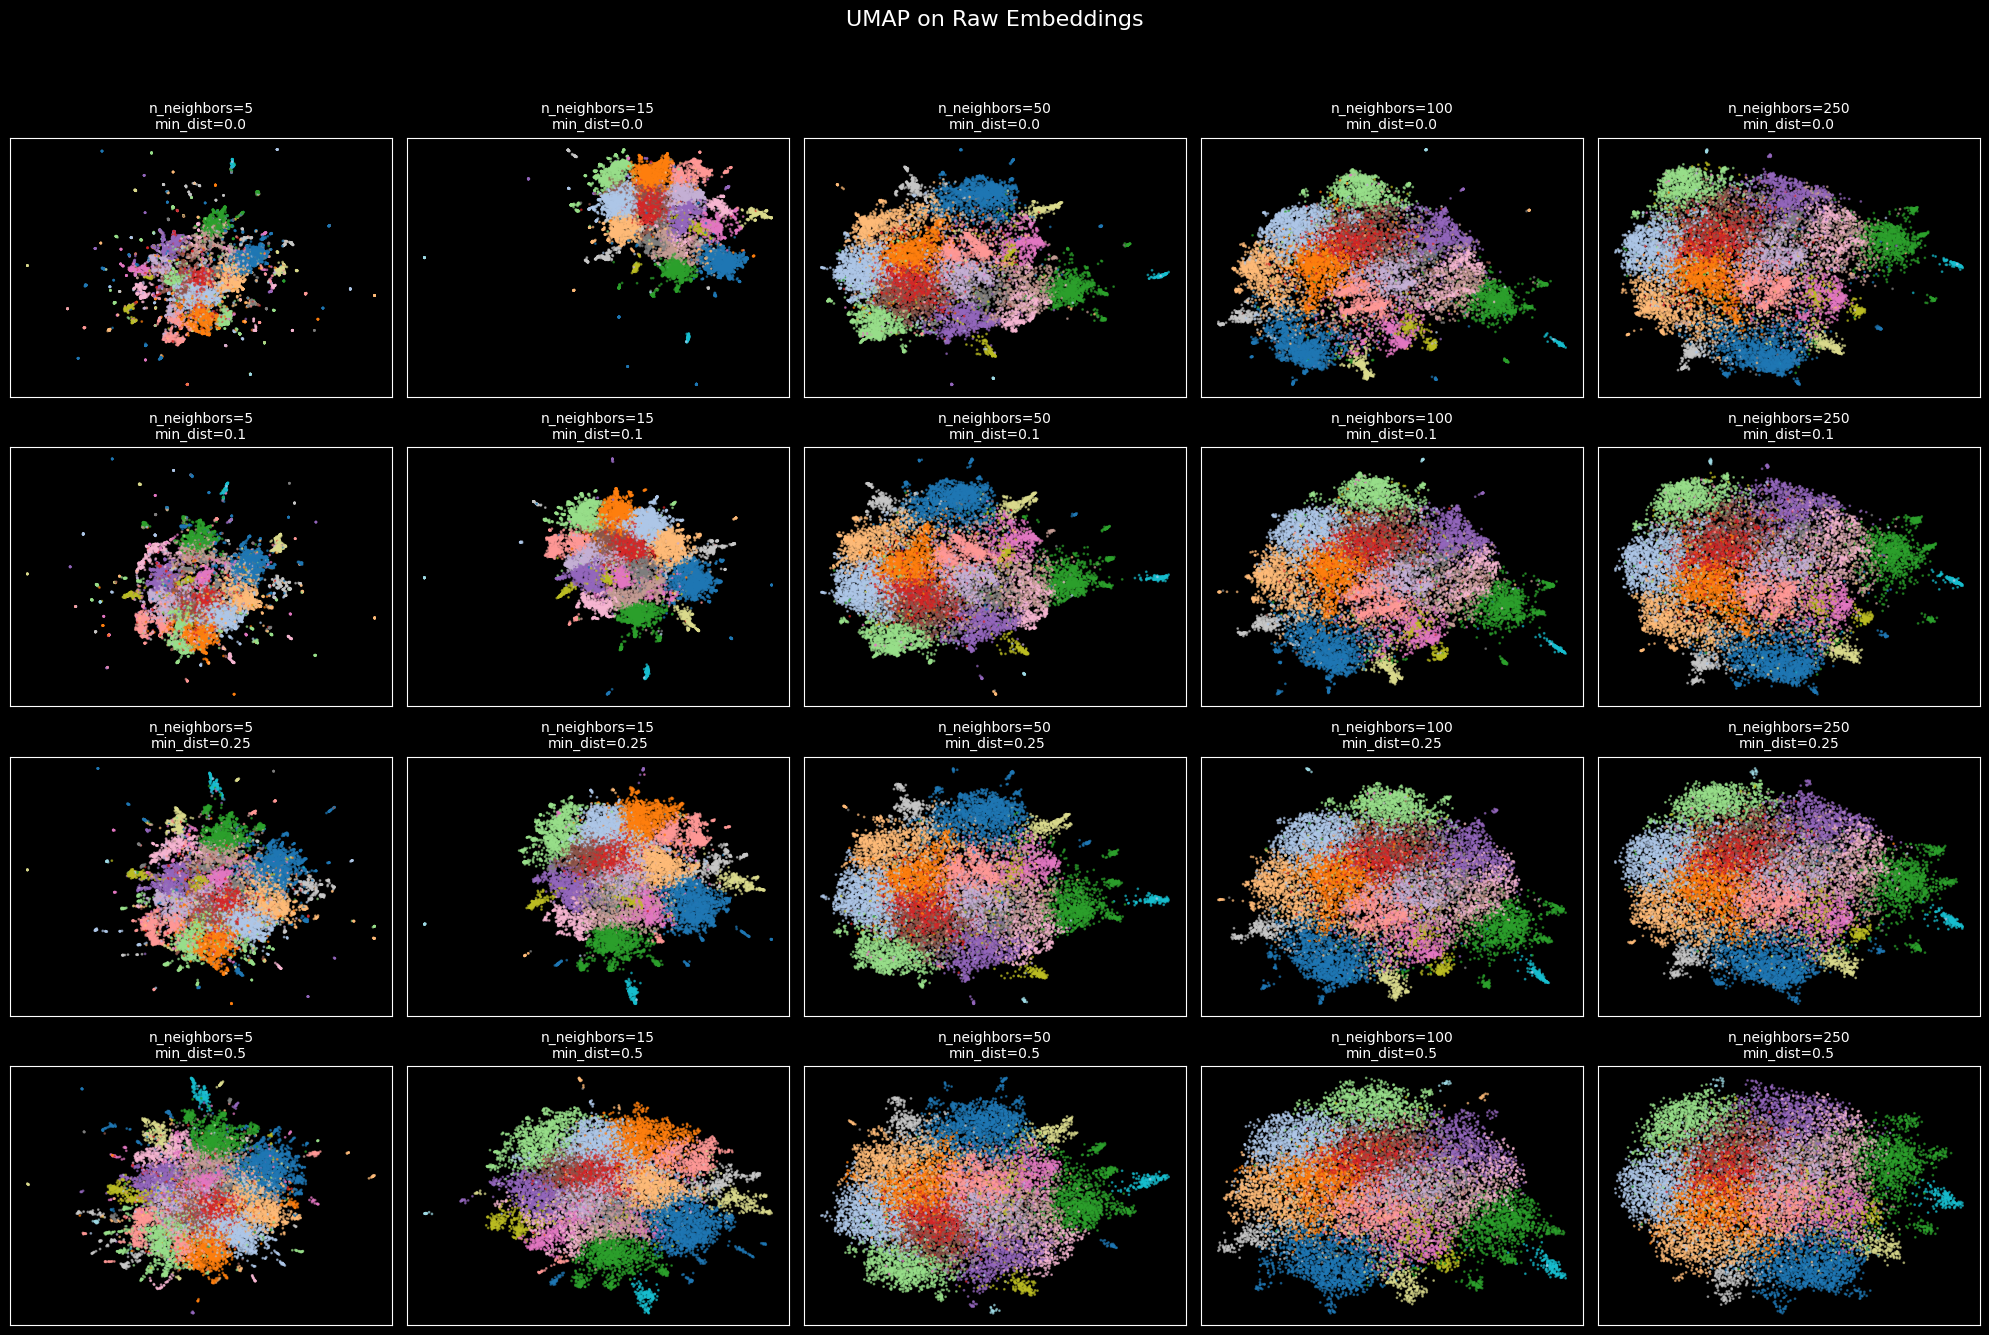

In [62]:
if 'embeddings' in locals():
    n_neighbors = [5, 15, 50, 100, 250]
    min_dist = [0.0, 0.1, 0.25, 0.5]

    common_params = {
        'n_components': 2,
        'metric': 'cosine',
        'random_state': 42
    }

    print("Generating umap grid...")
    plot_umap_grid(embeddings, colors, n_neighbors, min_dist, main_title="UMAP on Raw Embeddings", **common_params)
else:
    print("No embeddings present")

### PCA + UMAP

Generating pca + umap grid...


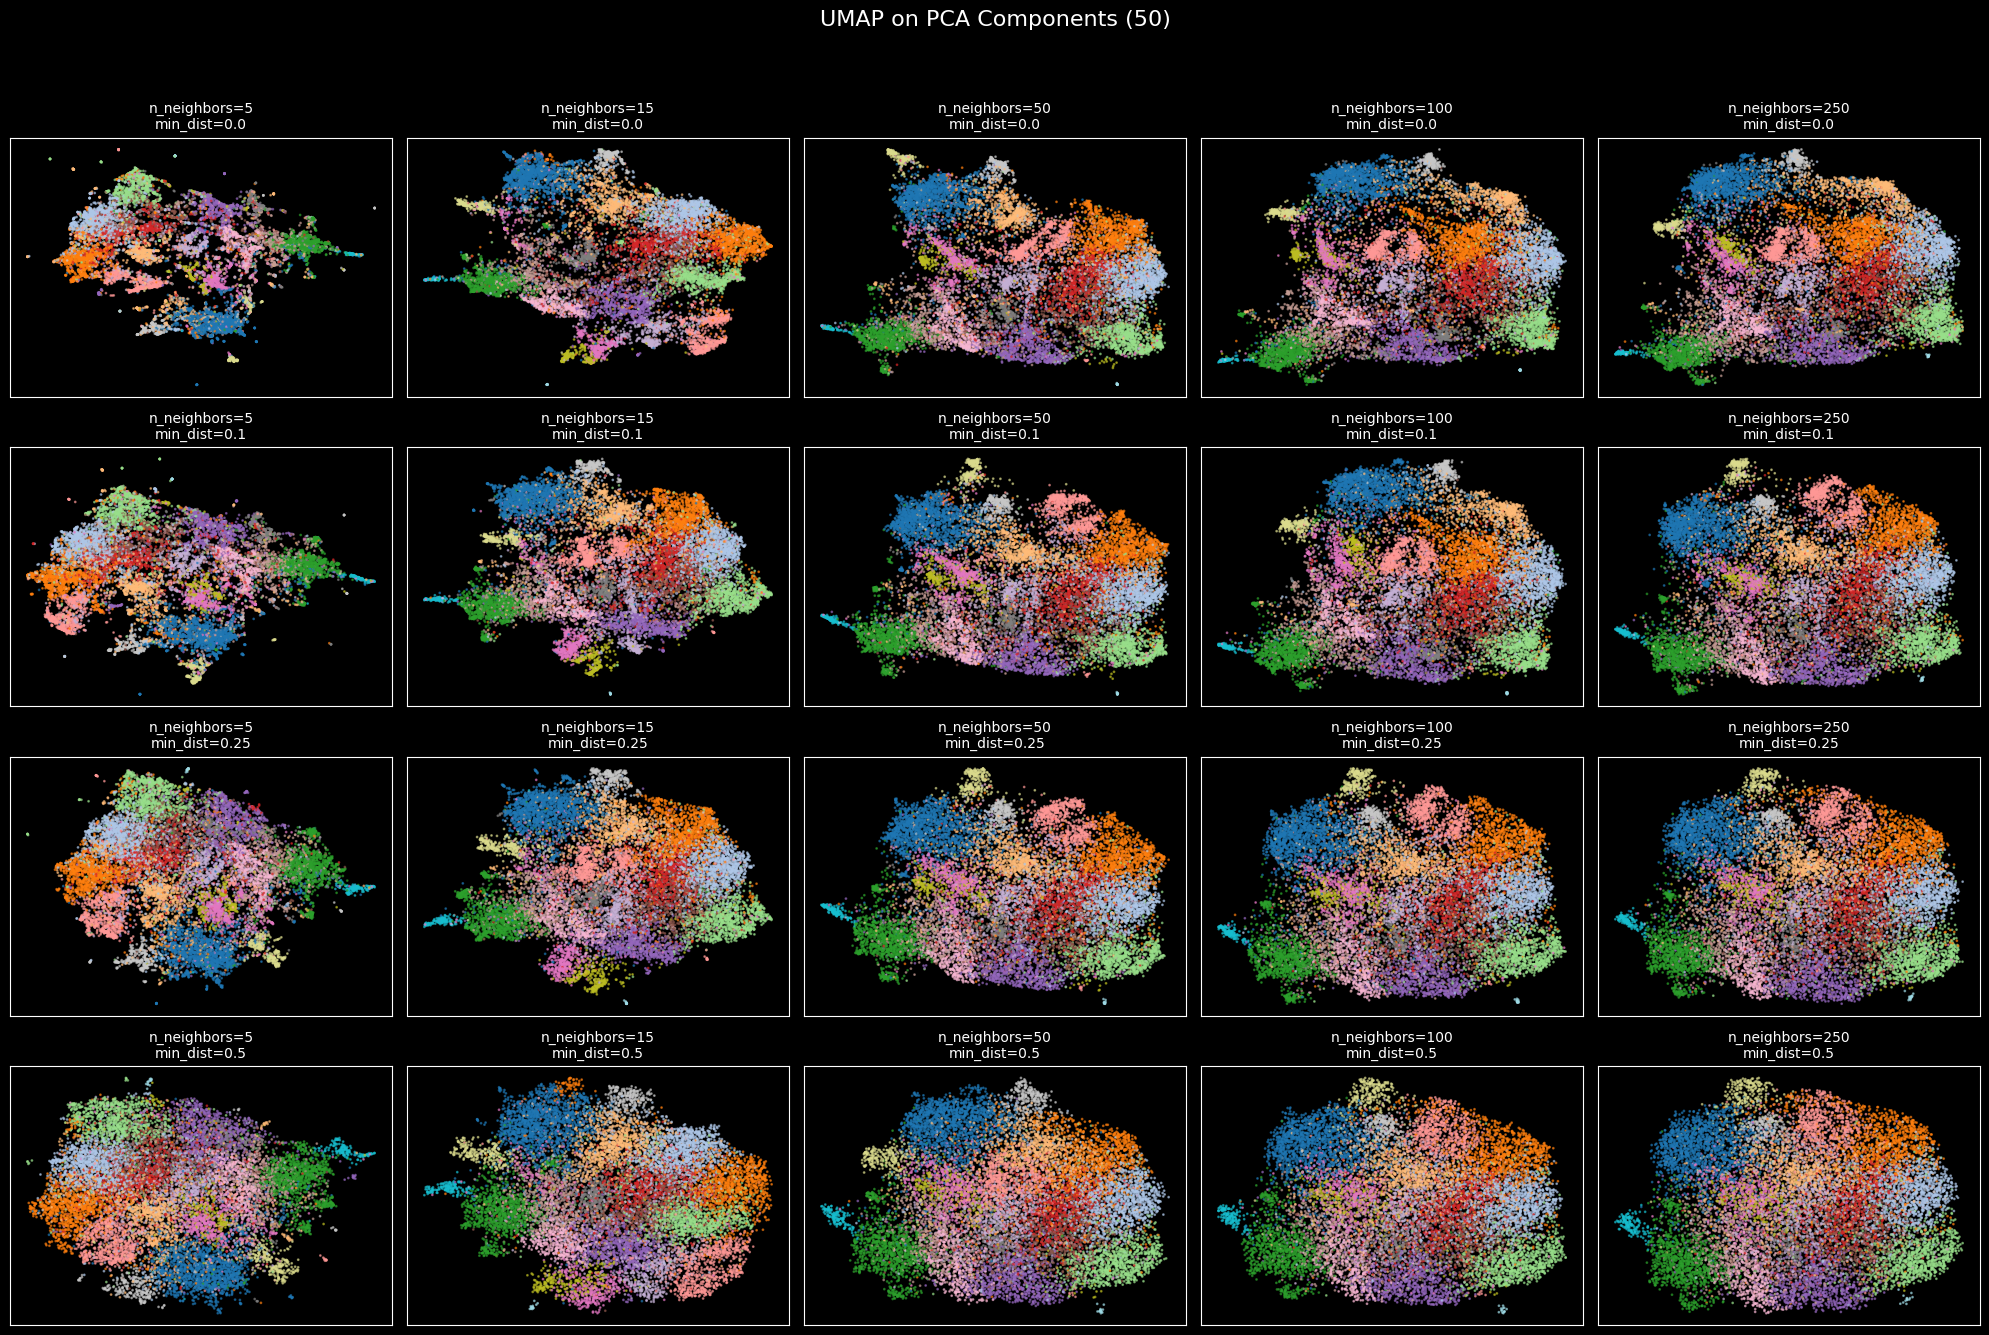

In [63]:
if 'embeddings' in locals():
    n_neighbors = [5, 15, 50, 100, 250]
    min_dist = [0.0, 0.1, 0.25, 0.5]

    common_params = {
        'n_components': 2,
        'metric': 'cosine',
        'random_state': 42
    }

    print("Generating pca + umap grid...")

    pca = PCA(n_components=50, random_state=42)
    embeddings_pca = pca.fit_transform(embeddings)

    plot_umap_grid(embeddings_pca, colors, n_neighbors, min_dist,
                   main_title="UMAP on PCA Components (50)", **common_params)
else:
    print("No embeddings present")

## 7. Saving book data

## 8. Adding a new book

In [ ]:
new_book = {
    'title': "Martyr!",
    'author': "Kaveh Akbar",
    'plot_summary': """
Cyrus is a queer poet living in Indiana, recovering from addiction to alcohol and drugs. His father, now deceased, was an Iranian migrant worker on a farm in rural Indiana. Cyrus believes that when he was a baby, his mother was killed on Iran Air Flight 655, a passenger plane which was shot down by a US missile during the Iran-Iraq war.

Cyrus is interested in the idea of martyrdom, and begins working on a "book of martyrs", while considering his own conceptual suicide as a potential martyr. He hears of an Iranian performance artist named Orkideh, who has terminal breast cancer, and is spending her last days in the Brooklyn Museum as part of a Marina Abramović-esque performance piece named "Death-Speak". Cyrus travels to New York to talk with Orkideh, bringing his roommate Zee. Zee has strong feelings for Cyrus, although their relationship is often fraught.

The book cycles between time periods and perspectives, including chapters told by Cyrus' mother, who was in a secret lesbian relationship in Iran, and his uncle, who, while serving in the Iran-Iraq war, was instructed to dress as an "angel" on horseback in order to comfort dying Iranian soldiers on the battlefield.

Upon Orkideh's death, Cyrus finds out from Sang - Orkideh's gallerist and ex-wife - that Orkideh was actually his mother, Roya. Roya had swapped passports with her lover Leila in order to escape Iran, and Leila was killed on the plane. In a dreamlike final scene, Cyrus appears to reconcile with Zee, before walking into a pool of golden light.
    """
}

new_embedding = model.encode([new_book['plot_summary']])

new_point = reducer.transform(new_embedding)

fig.add_scatter(
    x=[new_point[0, 0]],
    y=[new_point[0, 1]],
    mode="markers+text",
    text=["New Book"],
    marker=dict(size=12, color="red", symbol="x"),
    name="New Book"
)
fig.show()